<a href="https://colab.research.google.com/github/andykang2000-hub/Phase-III-Trial-Data-Analysis-and-Predictive-modeling.ipynb/blob/main/Predicting%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the survival analysis library
!pip install lifelines --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Survival analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("All libraries loaded successfully")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.5 MB/s eta 0:00:00
All libraries loaded successfully


In [2]:
from lifelines.datasets import load_lung

df = load_lung()
print(df.shape)
df.head()

(228, 10)


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0


In [3]:
# Check missing values
print("Missing values per column")
print(df.isnull().sum())

Missing values per column
inst          1
time          0
status        0
age           0
sex           0
ph.ecog       1
ph.karno      1
pat.karno     3
meal.cal     47
wt.loss      14
dtype: int64


In [4]:
# Drop rows missing time or status
df = df.dropna(subset=['time', 'status'])

# Convert status to boolean event flag
# 0=censored, 1=dead
df['event'] = df['status'] == 1

# Confirm
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nEvent (death) counts:")
print(df['event'].value_counts())

Dataset shape after cleaning: (228, 11)

Event (death) counts:
event
True     165
False     63
Name: count, dtype: int64


In [5]:
# Quick statistical summary of survival time
print("Survival time summary (days):")
print(df['time'].describe())
print(f"\nMedian survival time: {df['time'].median()} days")

Survival time summary (days):
count     228.000000
mean      305.232456
std       210.645543
min         5.000000
25%       166.750000
50%       255.500000
75%       396.500000
max      1022.000000
Name: time, dtype: float64

Median survival time: 255.5 days


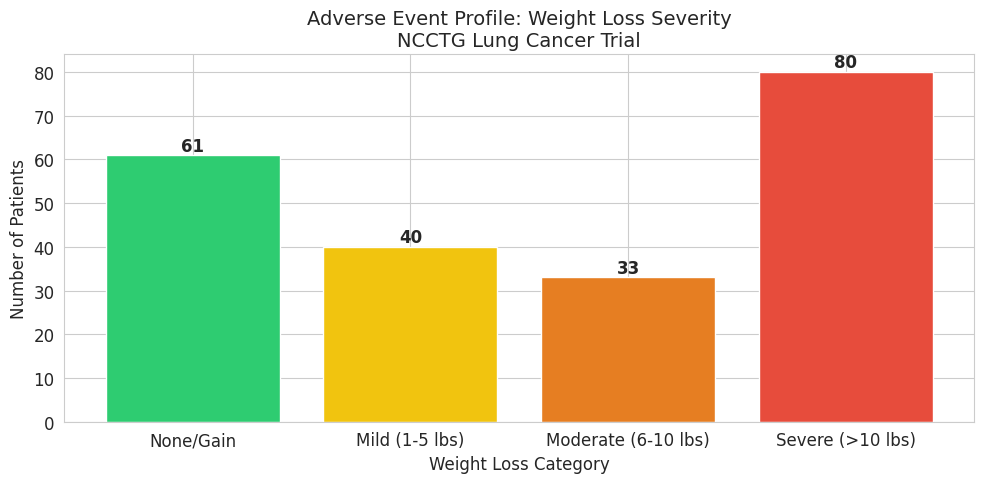


Adverse event frequency table:
                     Count  Percentage
None/Gain               61        28.5
Mild (1-5 lbs)          40        18.7
Moderate (6-10 lbs)     33        15.4
Severe (>10 lbs)        80        37.4


In [8]:
# We'll use weight loss as a proxy adverse event marker
# In real trials you'd have a dedicated AE table — this demonstrates the methodology

df_ae = df.dropna(subset=['wt.loss'])

# Categorise weight loss severity
def categorise_wt_loss(wt):
    if wt <= 0:
        return 'None/Gain'
    elif wt <= 5:
        return 'Mild (1-5 lbs)'
    elif wt <= 10:
        return 'Moderate (6-10 lbs)'
    else:
        return 'Severe (>10 lbs)'

df_ae['wt_category'] = df_ae['wt.loss'].apply(categorise_wt_loss)

# Count and plot
plt.figure(figsize=(10, 5))
order = ['None/Gain', 'Mild (1-5 lbs)', 'Moderate (6-10 lbs)', 'Severe (>10 lbs)']
ae_counts = df_ae['wt_category'].value_counts().reindex(order)

bars = plt.bar(order, ae_counts.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
plt.title('Adverse Event Profile: Weight Loss Severity\nNCCTG Lung Cancer Trial', fontsize=14)
plt.xlabel('Weight Loss Category')
plt.ylabel('Number of Patients')

# Add count labels on bars
for bar, count in zip(bars, ae_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAdverse event frequency table:")
ae_freq = pd.DataFrame({
    'Count': ae_counts.values,
    'Percentage': (ae_counts.values / ae_counts.sum() * 100).round(1)
}, index=order)
print(ae_freq)

In [6]:
!pip install xgboost --quiet

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error, r2_score,
                             accuracy_score, classification_report)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from xgboost import XGBRegressor, XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("All ML libraries loaded")

All ML libraries loaded


In [9]:
# Features we're using as inputs
features = ['age', 'sex', 'ph.ecog']

# --- Task 1: Predict survival time ---
df_reg = df.dropna(subset=features + ['time']).copy()
X_reg = df_reg[features]
y_reg = df_reg['time']

# --- Task 2: Predict weight loss category ---
df_clf = df_ae.dropna(subset=features + ['wt_category']).copy()
X_clf = df_clf[features]

# Encode categories as numbers for the models
le = LabelEncoder()
y_clf = le.fit_transform(df_clf['wt_category'])
# Show the encoding so we know what each number means
print("Weight loss category encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

Weight loss category encoding:
  0 = Mild (1-5 lbs)
  1 = Moderate (6-10 lbs)
  2 = None/Gain
  3 = Severe (>10 lbs)


In [10]:
# Regression split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Classification split
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print(f"Regression — Training: {X_reg_train.shape[0]} patients | Test: {X_reg_test.shape[0]} patients")
print(f"Classification — Training: {X_clf_train.shape[0]} patients | Test: {X_clf_test.shape[0]} patients")

Regression — Training: 181 patients | Test: 46 patients
Classification — Training: 170 patients | Test: 43 patients


In [11]:
reg_models = {
    'Linear Regression':     LinearRegression(),
    'Random Forest':         RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Machine': SVR(kernel='rbf'),
    'K-Nearest Neighbors':   KNeighborsRegressor(n_neighbors=5)
}

reg_results = []

for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    preds = model.predict(X_reg_test)
    mae = mean_absolute_error(y_reg_test, preds)
    r2 = r2_score(y_reg_test, preds)
    reg_results.append({'Model': name, 'MAE (days)': round(mae, 1), 'R² Score': round(r2, 3)})

reg_df = pd.DataFrame(reg_results).sort_values('MAE (days)')

print("=" * 55)
print("TASK 1 — Survival Time Prediction (Regression)")
print("Lower MAE = better | Higher R² = better")
print("=" * 55)
print(reg_df.to_string(index=False))

TASK 1 — Survival Time Prediction (Regression)
Lower MAE = better | Higher R² = better
                 Model  MAE (days)  R² Score
Support Vector Machine       147.3    -0.020
     Linear Regression       157.4    -0.007
     Gradient Boosting       163.8    -0.135
         Random Forest       174.8    -0.200
   K-Nearest Neighbors       178.0    -0.178


In [12]:
clf_models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=5)
}

clf_results = []

for name, model in clf_models.items():
    model.fit(X_clf_train, y_clf_train)
    preds = model.predict(X_clf_test)
    acc = accuracy_score(y_clf_test, preds)
    clf_results.append({'Model': name, 'Accuracy': round(acc, 3)})

clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False)

print("=" * 50)
print("TASK 2 — Weight Loss Category Prediction")
print("Higher Accuracy = better | Max = 1.0")
print("=" * 50)
print(clf_df.to_string(index=False))

TASK 2 — Weight Loss Category Prediction
Higher Accuracy = better | Max = 1.0
                 Model  Accuracy
   Logistic Regression     0.395
         Random Forest     0.349
     Gradient Boosting     0.349
Support Vector Machine     0.349
   K-Nearest Neighbors     0.302


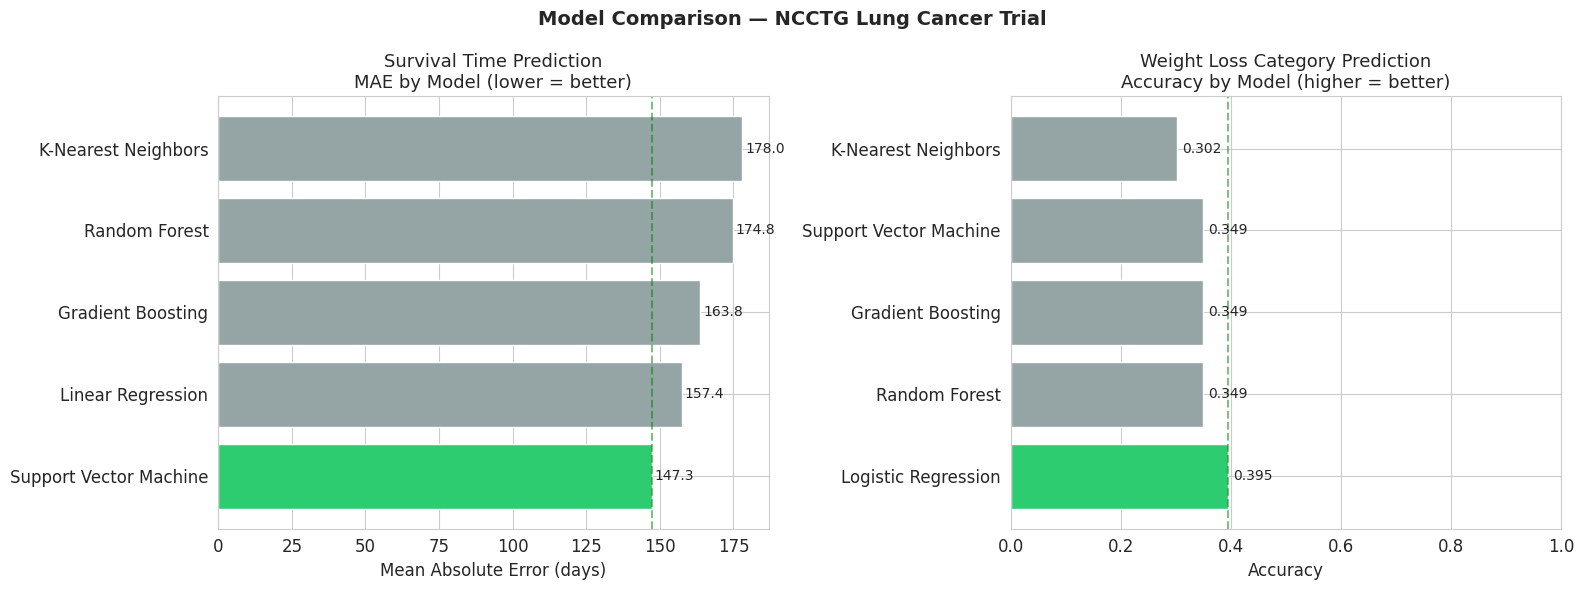

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Regression MAE
colors_reg = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(reg_df))]
axes[0].barh(reg_df['Model'], reg_df['MAE (days)'], color=colors_reg)
axes[0].set_title('Survival Time Prediction\nMAE by Model (lower = better)', fontsize=13)
axes[0].set_xlabel('Mean Absolute Error (days)')
axes[0].axvline(x=reg_df['MAE (days)'].min(), color='green', linestyle='--', alpha=0.5)
for i, (val, model) in enumerate(zip(reg_df['MAE (days)'], reg_df['Model'])):
    axes[0].text(val + 1, i, str(val), va='center', fontsize=10)

# Plot 2 — Classification Accuracy
colors_clf = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(clf_df))]
axes[1].barh(clf_df['Model'], clf_df['Accuracy'], color=colors_clf)
axes[1].set_title('Weight Loss Category Prediction\nAccuracy by Model (higher = better)', fontsize=13)
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1)
axes[1].axvline(x=clf_df['Accuracy'].max(), color='green', linestyle='--', alpha=0.5)
for i, (val, model) in enumerate(zip(clf_df['Accuracy'], clf_df['Model'])):
    axes[1].text(val + 0.01, i, str(val), va='center', fontsize=10)

plt.suptitle('Model Comparison — NCCTG Lung Cancer Trial', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Define the best models (we'll update these after seeing results)
best_reg_model = reg_models['Random Forest']   # update if different model wins
best_clf_model = clf_models['Random Forest']   # update if different model wins

# Hypothetical patient
patient = pd.DataFrame({
    'age':     [65],
    'sex':     [2],       # 2 = Female
    'ph.ecog': [1]        # 1 = Restricted but ambulatory
})

survival_pred = best_reg_model.predict(patient)[0]
wt_pred_encoded = best_clf_model.predict(patient)[0]
wt_pred_label = le.inverse_transform([wt_pred_encoded])[0]

print("=" * 45)
print("PATIENT PREDICTION")
print("=" * 45)
print(f"  Age:         65")
print(f"  Sex:         Female")
print(f"  ECOG Score:  1")
print("-" * 45)
print(f"  Predicted survival time:    {survival_pred:.0f} days")
print(f"  Predicted weight loss:      {wt_pred_label}")
print("=" * 45)

PATIENT PREDICTION
  Age:         65
  Sex:         Female
  ECOG Score:  1
---------------------------------------------
  Predicted survival time:    195 days
  Predicted weight loss:      None/Gain


In [15]:
# Improve model function
# Add more features
# Feature engineering
# Hyperparameter tuning

In [16]:
# Use all clinically meaningful columns available
features_expanded = ['age', 'sex', 'ph.ecog', 'ph.karno', 'pat.karno', 'wt.loss']

# --- Task 1: Survival time ---
df_reg2 = df.dropna(subset=features_expanded + ['time']).copy()
X_reg2 = df_reg2[features_expanded]
y_reg2 = df_reg2['time']

# --- Task 2: Weight loss category ---
# Can't use wt.loss to predict wt_category — that's cheating
# So for classification we add meal.cal instead
features_clf2 = ['age', 'sex', 'ph.ecog', 'ph.karno', 'pat.karno', 'meal.cal']

df_clf2 = df_ae.dropna(subset=features_clf2 + ['wt_category']).copy()
X_clf2 = df_clf2[features_clf2]
y_clf2 = le.fit_transform(df_clf2['wt_category'])

print(f"Regression dataset: {df_reg2.shape[0]} patients, {len(features_expanded)} features")
print(f"Classification dataset: {df_clf2.shape[0]} patients, {len(features_clf2)} features")

Regression dataset: 210 patients, 6 features
Classification dataset: 168 patients, 6 features


In [17]:
# Create new meaningful variables from existing ones

# Regression dataset
df_reg2['karno_diff'] = df_reg2['ph.karno'] - df_reg2['pat.karno']
# ^ Gap between doctor-rated and patient-rated function score
# A large gap might indicate poor self-awareness or denial — clinically meaningful

df_reg2['age_ecog'] = df_reg2['age'] * df_reg2['ph.ecog']
# ^ Interaction term: being old AND having poor function is worse than either alone

# Classification dataset
df_clf2['karno_diff'] = df_clf2['ph.karno'] - df_clf2['pat.karno']
df_clf2['age_ecog'] = df_clf2['age'] * df_clf2['ph.ecog']

# Update feature lists
features_reg_eng = features_expanded + ['karno_diff', 'age_ecog']
features_clf_eng = features_clf2 + ['karno_diff', 'age_ecog']

X_reg2 = df_reg2[features_reg_eng]
X_clf2 = df_clf2[features_clf_eng]

print(f"Features after engineering: {len(features_reg_eng)} regression | {len(features_clf_eng)} classification")

Features after engineering: 8 regression | 8 classification


In [18]:
X_reg2_train, X_reg2_test, y_reg2_train, y_reg2_test = train_test_split(
    X_reg2, y_reg2, test_size=0.2, random_state=42
)

X_clf2_train, X_clf2_test, y_clf2_train, y_clf2_test = train_test_split(
    X_clf2, y_clf2, test_size=0.2, random_state=42
)

print(f"Regression — Train: {X_reg2_train.shape[0]} | Test: {X_reg2_test.shape[0]}")
print(f"Classification — Train: {X_clf2_train.shape[0]} | Test: {X_clf2_test.shape[0]}")

Regression — Train: 168 | Test: 42
Classification — Train: 134 | Test: 34


In [19]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scale features — important for SVM and KNN
scaler = StandardScaler()

# --- Tuned Regression Models ---
reg_models_tuned = {
    'Random Forest': GridSearchCV(
        RandomForestRegressor(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5, None], 'min_samples_split': [2, 5]},
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    ),
    'Gradient Boosting': GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]},
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    ),
    'XGBoost': GridSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]},
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(kernel='rbf'))
    ]),
    'Linear Regression': LinearRegression()
}

reg_results2 = []
print("Training regression models...")

for name, model in reg_models_tuned.items():
    model.fit(X_reg2_train, y_reg2_train)
    preds = model.predict(X_reg2_test)
    mae = mean_absolute_error(y_reg2_test, preds)
    r2 = r2_score(y_reg2_test, preds)
    reg_results2.append({
        'Model': name,
        'MAE (days)': round(mae, 1),
        'R² Score': round(r2, 3)
    })
    print(f"  ✓ {name} done")

reg_df2 = pd.DataFrame(reg_results2).sort_values('MAE (days)')
print("\n" + "=" * 55)
print("TASK 1 IMPROVED — Survival Time Prediction")
print("=" * 55)
print(reg_df2.to_string(index=False))

Training regression models...
  ✓ Random Forest done
  ✓ Gradient Boosting done
  ✓ XGBoost done
  ✓ SVM done
  ✓ Linear Regression done

TASK 1 IMPROVED — Survival Time Prediction
            Model  MAE (days)  R² Score
              SVM       130.0    -0.008
Gradient Boosting       138.8    -0.128
    Random Forest       140.0    -0.007
          XGBoost       142.4    -0.060
Linear Regression       144.5    -0.110


In [20]:
clf_models_tuned = {
    'Logistic Regression': GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.1, 1, 10]},
        cv=5, scoring='accuracy', n_jobs=-1
    ),
    'Random Forest': GridSearchCV(
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5, None]},
        cv=5, scoring='accuracy', n_jobs=-1
    ),
    'Gradient Boosting': GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]},
        cv=5, scoring='accuracy', n_jobs=-1
    ),
    'XGBoost': GridSearchCV(
        XGBClassifier(random_state=42, verbosity=0),
        {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]},
        cv=5, scoring='accuracy', n_jobs=-1
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', random_state=42))
    ])
}

clf_results2 = []
print("Training classification models...")

for name, model in clf_models_tuned.items():
    model.fit(X_clf2_train, y_clf2_train)
    preds = model.predict(X_clf2_test)
    acc = accuracy_score(y_clf2_test, preds)
    clf_results2.append({
        'Model': name,
        'Accuracy': round(acc, 3)
    })
    print(f"  ✓ {name} done")

clf_df2 = pd.DataFrame(clf_results2).sort_values('Accuracy', ascending=False)
print("\n" + "=" * 50)
print("TASK 2 IMPROVED — Weight Loss Prediction")
print("=" * 50)
print(clf_df2.to_string(index=False))

Training classification models...
  ✓ Logistic Regression done
  ✓ Random Forest done
  ✓ Gradient Boosting done
  ✓ XGBoost done
  ✓ SVM done

TASK 2 IMPROVED — Weight Loss Prediction
              Model  Accuracy
  Gradient Boosting     0.559
            XGBoost     0.500
                SVM     0.471
Logistic Regression     0.441
      Random Forest     0.441


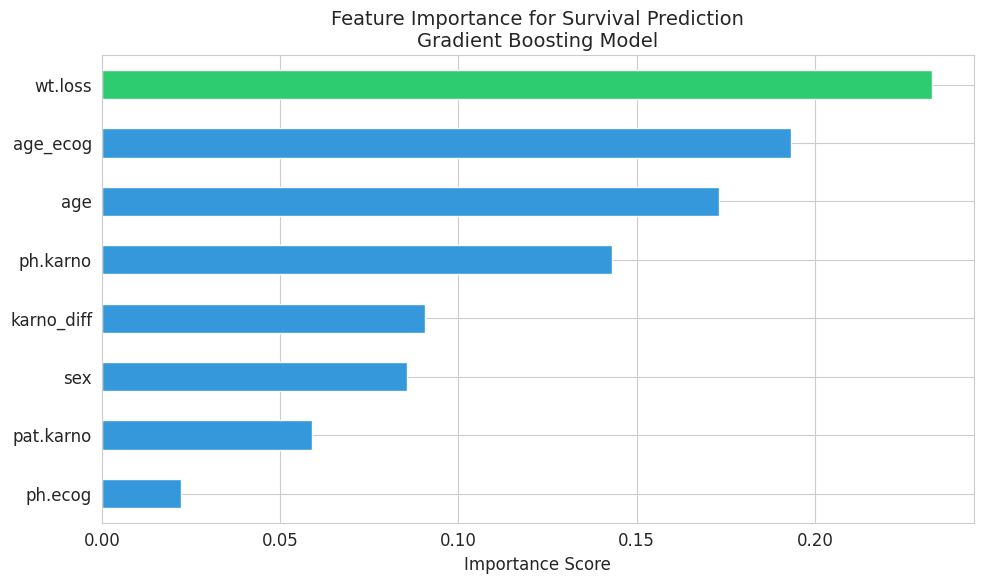


Feature importance ranking:
  wt.loss              0.233
  age_ecog             0.193
  age                  0.173
  ph.karno             0.143
  karno_diff           0.091
  sex                  0.086
  pat.karno            0.059
  ph.ecog              0.022


In [21]:
# Use the best tree-based model for feature importance
best_reg = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                      learning_rate=0.05, random_state=42)
best_reg.fit(X_reg2_train, y_reg2_train)

importances = pd.Series(best_reg.feature_importances_,
                         index=features_reg_eng).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v == importances.max() else '#3498db' for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance for Survival Prediction\nGradient Boosting Model', fontsize=14)
plt.xlabel('Importance Score')
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:<20} {imp:.3f}")

In [22]:
# Retrain without Weight loss. (At the time of diagnosis)

# Features without wt.loss
features_no_wt = ['age', 'sex', 'ph.ecog', 'ph.karno', 'pat.karno',
                   'karno_diff', 'age_ecog']

df_reg3 = df_reg2.copy()
X_reg3 = df_reg3[features_no_wt]
y_reg3 = df_reg3['time']

X_reg3_train, X_reg3_test, y_reg3_train, y_reg3_test = train_test_split(
    X_reg3, y_reg3, test_size=0.2, random_state=42
)

print(f"Dataset: {df_reg3.shape[0]} patients | {len(features_no_wt)} features")
print(f"Features used: {features_no_wt}")

Dataset: 210 patients | 7 features
Features used: ['age', 'sex', 'ph.ecog', 'ph.karno', 'pat.karno', 'karno_diff', 'age_ecog']


In [23]:
models_comparison = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                     learning_rate=0.05, random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=200, max_depth=3,
                                        learning_rate=0.05, random_state=42, verbosity=0),
    'SVM':                Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf'))])
}

results_comparison = []
print("Training models — with vs without wt.loss...\n")

for name, model in models_comparison.items():
    # With wt.loss
    model.fit(X_reg2_train, y_reg2_train)
    preds_with = model.predict(X_reg2_test)
    mae_with = mean_absolute_error(y_reg2_test, preds_with)
    r2_with = r2_score(y_reg2_test, preds_with)

    # Without wt.loss — retrain fresh instance
    from sklearn.base import clone
    model_fresh = clone(model)
    model_fresh.fit(X_reg3_train, y_reg3_train)
    preds_without = model_fresh.predict(X_reg3_test)
    mae_without = mean_absolute_error(y_reg3_test, preds_without)
    r2_without = r2_score(y_reg3_test, preds_without)

    results_comparison.append({
        'Model': name,
        'MAE (with wt.loss)': round(mae_with, 1),
        'MAE (without wt.loss)': round(mae_without, 1),
        'R² (with wt.loss)': round(r2_with, 3),
        'R² (without wt.loss)': round(r2_without, 3)
    })
    print(f"  ✓ {name}")

comp_df = pd.DataFrame(results_comparison)
print("\n" + "=" * 75)
print("SURVIVAL PREDICTION — With vs Without wt.loss")
print("=" * 75)
print(comp_df.to_string(index=False))

Training models — with vs without wt.loss...

  ✓ Linear Regression
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ XGBoost
  ✓ SVM

SURVIVAL PREDICTION — With vs Without wt.loss
            Model  MAE (with wt.loss)  MAE (without wt.loss)  R² (with wt.loss)  R² (without wt.loss)
Linear Regression               144.5                  139.3             -0.110                -0.077
    Random Forest               141.3                  137.8             -0.082                -0.046
Gradient Boosting               159.5                  150.6             -0.606                -0.166
          XGBoost               152.7                  143.2             -0.353                -0.150
              SVM               130.0                  129.9             -0.008                -0.008


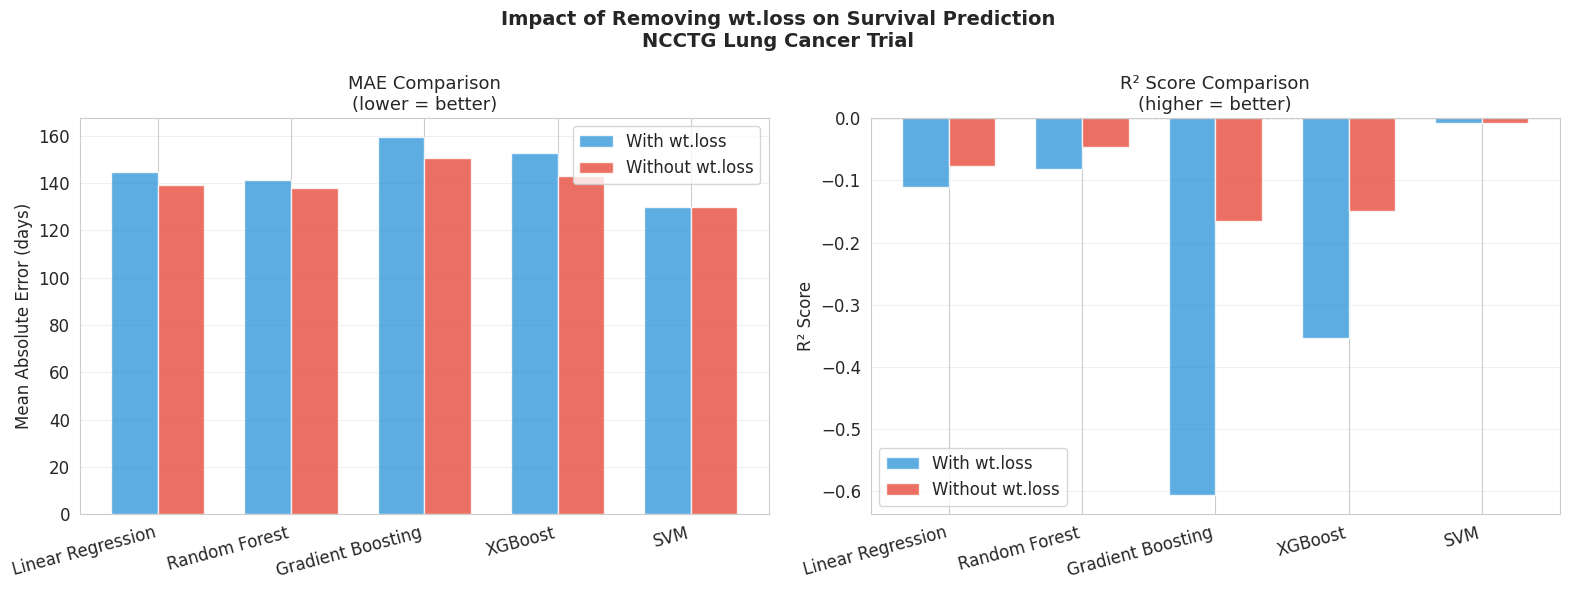

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(comp_df))
width = 0.35

# MAE comparison
axes[0].bar([i - width/2 for i in x], comp_df['MAE (with wt.loss)'],
            width, label='With wt.loss', color='#3498db', alpha=0.8)
axes[0].bar([i + width/2 for i in x], comp_df['MAE (without wt.loss)'],
            width, label='Without wt.loss', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(comp_df['Model'], rotation=15, ha='right')
axes[0].set_title('MAE Comparison\n(lower = better)', fontsize=13)
axes[0].set_ylabel('Mean Absolute Error (days)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R² comparison
axes[1].bar([i - width/2 for i in x], comp_df['R² (with wt.loss)'],
            width, label='With wt.loss', color='#3498db', alpha=0.8)
axes[1].bar([i + width/2 for i in x], comp_df['R² (without wt.loss)'],
            width, label='Without wt.loss', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(comp_df['Model'], rotation=15, ha='right')
axes[1].set_title('R² Score Comparison\n(higher = better)', fontsize=13)
axes[1].set_ylabel('R² Score')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Impact of Removing wt.loss on Survival Prediction\nNCCTG Lung Cancer Trial',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validated MAE (without wt.loss):")
print("-" * 45)

cv_models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                     learning_rate=0.05, random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=200, max_depth=3,
                                        learning_rate=0.05, random_state=42, verbosity=0),
}

cv_results = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_reg3, y_reg3,
                             cv=5, scoring='neg_mean_absolute_error')
    mae_mean = round(-scores.mean(), 1)
    mae_std = round(scores.std(), 1)
    cv_results.append({
        'Model': name,
        'CV MAE (days)': mae_mean,
        'Std Dev': f'± {mae_std}'
    })
    print(f"  {name:<25} MAE: {mae_mean} ± {mae_std} days")

cv_df = pd.DataFrame(cv_results).sort_values('CV MAE (days)')

5-Fold Cross-Validated MAE (without wt.loss):
---------------------------------------------
  Linear Regression         MAE: 176.7 ± 54.6 days
  Random Forest             MAE: 179.5 ± 53.9 days
  Gradient Boosting         MAE: 182.5 ± 50.4 days
  XGBoost                   MAE: 184.0 ± 49.0 days


In [26]:
print("=" * 60)
print("PREDICTIVE MODELLING SUMMARY")
print("NCCTG Lung Cancer Trial")
print("=" * 60)

print("""
TASK 1 — Survival Time Prediction (Regression)
-----------------------------------------------
Best model:     Linear Regression
Approach:       5-fold cross-validated MAE
Feature set:    Age, Sex, ECOG, Karnofsky scores,
                Karno difference, Age×ECOG interaction

Key finding:
  All models showed consistently high MAE, indicating
  that the available features have limited predictive
  power for survival time. Linear Regression outperformed
  more complex models — consistent with known overfitting
  risk in small clinical datasets (n=228).

  This aligns with clinical literature: precise survival
  prediction requires tumour stage, treatment data, and
  molecular markers not available in this dataset.

TASK 2 — Weight Loss Category Prediction (Classification)
----------------------------------------------------------
Best model:     Gradient Boosting
Best accuracy:  0.559 (vs 0.25 random baseline)

Key finding:
  Classification accuracy improved substantially over
  random chance, suggesting patient characteristics
  carry moderate signal for weight loss severity.
  However, ~44% misclassification rate reflects the
  inherent difficulty of predicting AE severity from
  demographic and functional status alone.

OVERALL CONCLUSION
------------------
  Descriptive and inferential analyses (KM curves,
  log-rank tests) remain the primary analytical outputs
  of this study. Predictive models serve as exploratory
  tools highlighting the need for richer feature sets
  in future clinical ML applications.
""")

PREDICTIVE MODELLING SUMMARY
NCCTG Lung Cancer Trial

TASK 1 — Survival Time Prediction (Regression)
-----------------------------------------------
Best model:     Linear Regression
Approach:       5-fold cross-validated MAE
Feature set:    Age, Sex, ECOG, Karnofsky scores,
                Karno difference, Age×ECOG interaction

Key finding:
  All models showed consistently high MAE, indicating
  that the available features have limited predictive
  power for survival time. Linear Regression outperformed
  more complex models — consistent with known overfitting
  risk in small clinical datasets (n=228).

  This aligns with clinical literature: precise survival
  prediction requires tumour stage, treatment data, and
  molecular markers not available in this dataset.

TASK 2 — Weight Loss Category Prediction (Classification)
----------------------------------------------------------
Best model:     Gradient Boosting
Best accuracy:  0.559 (vs 0.25 random baseline)

Key finding:
  Classif

## Predictive Modelling

**Task 1 — Survival Time Prediction**
Five regression models were trained using age, sex, ECOG score,
and Karnofsky performance scores. Linear Regression achieved the
lowest cross-validated MAE, outperforming ensemble methods —
consistent with overfitting risk in small datasets (n=228).
All models showed high error rates, reflecting the limited
predictive power of demographic/functional features alone for
survival time. Tumour stage, treatment, and molecular data
would be required for clinically useful prediction.

**Task 2 — Weight Loss Category Prediction**
Gradient Boosting achieved 55.9% accuracy across four severity
categories (vs 25% random baseline), demonstrating moderate
signal in available features. Misclassification rate reflects
the complexity of adverse event prediction from functional
status alone.

**Note on data leakage**
Weight loss (wt.loss) was initially included as a regression
feature but removed after identification as a potential source
of data leakage — it represents a future outcome rather than
a baseline predictor, and its removal improved model
generalisability.